# Visualización de Datos
Este notebook comprenderá las gráficas exploratorias de los datos. De esta manera, buscaremos obtener información, en primera instancia, de posibles dinámicas temporales, distribución de los datos (para informar que se pruebas estadísticas se realizarán) y relaciones preliminares.

## A. Cargamos librerías y datos.

In [2]:
# Librerías.

import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey
import seaborn as sns
from joblib import load
import plotly.graph_objects as go

In [3]:
# Datos

in_file = "data_clean/DALYs_clean_unificado_NEW.pkl"
with open(in_file, 'rb') as f:
     df = load(f)
display(df)
print(df.columns.tolist())

,ano,pais,codigo_pais,codigo_ghe,categoria_principal,categoria_nivel1,categoria_nivel2,causa,sexo,edad,...,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,poblacion_abs,tasa_dalys_100k,dalys_por_intervencion,desarrollo_vs_carga
0,2000,Afghanistan,AFG,210.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,NaN,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,1.700371e+00,1.746827e-05,NaN
1,2000,Afghanistan,AFG,220.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,a.Malaria,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,5.747056e-01,6.211615e-06,NaN
2,2000,Afghanistan,AFG,230.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,b.Trypanosomiasis,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000e+00,4.645592e-07,NaN
3,2000,Afghanistan,AFG,240.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,c.Chagas disease,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000e+00,4.645592e-07,NaN
4,2000,Afghanistan,AFG,250.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,d.Schistosomiasis,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000e+00,4.645592e-07,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310795,2021,Zimbabwe,ZWE,340.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,a.Ascariasis,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,2.124487e-03,5.198515e-06,1.142974e-03
310796,2021,Zimbabwe,ZWE,350.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,b.Trichuriasis,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,1.551167e-09,5.177270e-06,8.345278e-10
310797,2021,Zimbabwe,ZWE,360.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,c.Hookworm disease,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,6.356956e-02,5.812965e-06,3.420042e-02
310798,2021,Zimbabwe,ZWE,362.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,d.Food-borne trematodes,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,0.000000e+00,5.177270e-06,0.000000e+00


['ano', 'pais', 'codigo_pais', 'codigo_ghe', 'categoria_principal', 'categoria_nivel1', 'categoria_nivel2', 'causa', 'sexo', 'edad', 'dalys', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'poblacion_abs', 'tasa_dalys_100k', 'dalys_por_intervencion', 'desarrollo_vs_carga']


In [5]:
# Tipos de datos
df.dtypes

ano                           int64
pais                       category
codigo_pais                category
codigo_ghe                 category
categoria_principal        category
categoria_nivel1           category
categoria_nivel2           category
causa                      category
sexo                       category
edad                       category
dalys                       float64
pib_per_capita              float64
idh                         float64
indice_educacion            float64
indice_salud                float64
indice_ingresos             float64
esperanza_vida              float64
poblacion_miles             float64
co2_anual                   float64
precipitacion_total         float64
temperatura_superficial     float64
humedad_relativa            float64
poblacion_abs               float64
tasa_dalys_100k             float64
dalys_por_intervencion      float64
desarrollo_vs_carga         float64
dtype: object

## B. Generación de gráficas.
Dado que es difícil manejar los datos con los DALYs separados por enfermedad, se modificará para el análisis global en una variable de DALYs totales.

In [10]:
# ============================================
# Agregar DALYs por año y país (o por año)
# ============================================

# Agregar por año (visión global)
dalys_por_año = df.groupby('ano')['dalys'].sum().reset_index()

# Agregar por año y país (para ver diferencias entre países)
dalys_por_año_pais = df.groupby(['ano', 'pais'])['dalys'].sum().reset_index()

# gregar por año y categoría principal (recomendado)
dalys_por_año_categoria = df.groupby(['ano', 'causa'])['dalys'].sum().reset_index()

# ============================================
# Obtener variables contextuales por año
# ============================================

vars_contextuales = ['pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 
                     'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 
                     'co2_anual', 'precipitacion_total', 'temperatura_superficial', 
                     'humedad_relativa', 'poblacion_abs']

# Tomar valores únicos por año (eliminando redundancia)
vars_unicas_por_año = df.groupby('ano')[vars_contextuales].first().reset_index()

# ============================================
# Combinar datos agregados con variables contextuales
# ============================================

# Para análisis global por año
df_analisis_global = pd.merge(dalys_por_año, vars_unicas_por_año, on='ano')

# Para análisis por país
df_analisis_pais = pd.merge(dalys_por_año_pais, vars_unicas_por_año, on='ano')

# Para análisis por categoría
df_analisis_categoria = pd.merge(dalys_por_año_categoria, vars_unicas_por_año, on='ano')

print("✅ Datos agregados correctamente:")
print(f"Filas originales: {len(df):,}")
print(f"Filas después de agregar por año: {len(df_analisis_global)}")
print(f"Filas después de agregar por año y país: {len(df_analisis_pais)}")


✅ Datos agregados correctamente:
Filas originales: 242,956
Filas después de agregar por año: 6
Filas después de agregar por año y país: 1110


C:\Users\troop\AppData\Local\Temp\ipykernel_20536\2994199521.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_por_año_pais = df.groupby(['ano', 'pais'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_20536\2994199521.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_por_año_categoria = df.groupby(['ano', 'causa'])['dalys'].sum().reset_index()


### Relaciones temporales

In [11]:
# ============================================
# PRIMERO: Definir las variables
# ============================================

# Lista de variables contextuales que se repiten por año
vars_contextuales = ['pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 
                     'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 
                     'co2_anual', 'precipitacion_total', 'temperatura_superficial', 
                     'humedad_relativa', 'poblacion_abs']

# Crear vars_por_año (valores únicos por año)
vars_por_año = df.groupby('ano')[vars_contextuales].first().reset_index()

# ============================================
# PASO 1: Agregar datos incluyendo CAUSA como primera dimensión
# ============================================

# Agrupar por todas las dimensiones
dalys_5capas = df.groupby(['ano', 'causa', 'pais', 'edad', 'sexo'])['dalys'].sum().reset_index()

# Combinar con variables contextuales
df_5capas = pd.merge(dalys_5capas, vars_por_año, on='ano')

# ============================================
# PASO 2: Seleccionar datos (limitar para no saturar)
# ============================================

# Seleccionar top causas (primera capa)
top_causas = df_5capas.groupby('causa')['dalys'].sum().nlargest(8).index.tolist()

# Seleccionar top países (segunda capa)
top_paises = df_5capas.groupby('pais')['dalys'].sum().nlargest(6).index.tolist()

# Obtener categorías únicas
categorias_edad = sorted(df_5capas['edad'].unique())
sexos = df_5capas['sexo'].unique().tolist()

# Seleccionar años (cada 3 años para reducir densidad)
años_seleccionados = sorted(df_5capas['ano'].unique())[::1]

# Filtrar datos
df_filtered = df_5capas[
    (df_5capas['causa'].isin(top_causas)) &
    (df_5capas['pais'].isin(top_paises)) &
    (df_5capas['ano'].isin(años_seleccionados))
]

print(f"Causas: {len(top_causas)}")
print(f"Países: {len(top_paises)}")
print(f"Edades: {len(categorias_edad)}")
print(f"Sexos: {len(sexos)}")
print(f"Años: {len(años_seleccionados)}")

# ============================================
# PASO 3: Crear nodos para 5 capas (Causa → País → Edad → Sexo → Año)
# ============================================

causas_list = list(top_causas)
paises_list = list(top_paises)
edades_list = list(categorias_edad)
sexos_list = list(sexos)
años_list = [f"Año {int(año)}" for año in años_seleccionados]

# Combinar todas las etiquetas en el orden correcto
labels = causas_list + paises_list + edades_list + sexos_list + años_list

# Calcular offsets para cada capa
offset_causas = 0
offset_paises = len(causas_list)
offset_edades = len(causas_list) + len(paises_list)
offset_sexos = len(causas_list) + len(paises_list) + len(edades_list)
offset_años = len(causas_list) + len(paises_list) + len(edades_list) + len(sexos_list)

# ============================================
# PASO 4: Crear links entre capas
# ============================================

sources = []
targets = []
values = []

# Capa 1: Causa → País
print("Creando links Causa → País...")
for causa in top_causas:
    for pais in top_paises:
        valor = df_filtered[(df_filtered['causa'] == causa) & 
                            (df_filtered['pais'] == pais)]['dalys'].sum()
        if valor > 0:
            sources.append(causas_list.index(causa) + offset_causas)
            targets.append(paises_list.index(pais) + offset_paises)
            values.append(valor)

# Capa 2: País → Edad
print("Creando links País → Edad...")
for pais in top_paises:
    for edad in categorias_edad:
        valor = df_filtered[(df_filtered['pais'] == pais) & 
                            (df_filtered['edad'] == edad)]['dalys'].sum()
        if valor > 0:
            sources.append(paises_list.index(pais) + offset_paises)
            targets.append(edades_list.index(edad) + offset_edades)
            values.append(valor)

# Capa 3: Edad → Sexo
print("Creando links Edad → Sexo...")
for edad in categorias_edad:
    for sexo in sexos_list:
        valor = df_filtered[(df_filtered['edad'] == edad) & 
                            (df_filtered['sexo'] == sexo)]['dalys'].sum()
        if valor > 0:
            sources.append(edades_list.index(edad) + offset_edades)
            targets.append(sexos_list.index(sexo) + offset_sexos)
            values.append(valor)

# Capa 4: Sexo → Año
print("Creando links Sexo → Año...")
for sexo in sexos_list:
    for año in años_seleccionados:
        valor = df_filtered[(df_filtered['sexo'] == sexo) & 
                            (df_filtered['ano'] == año)]['dalys'].sum()
        if valor > 0:
            sources.append(sexos_list.index(sexo) + offset_sexos)
            targets.append(años_list.index(f"Año {int(año)}") + offset_años)
            values.append(valor)

print(f"Total de links creados: {len(sources)}")

# ============================================
# PASO 5: Crear figura con colores por capa
# ============================================

# Definir colores para cada capa
colores = (["#FF6B6B"] * len(causas_list) +      # Rojo para causas
           ["#4ECDC4"] * len(paises_list) +      # Turquesa para países
           ["#95E77E"] * len(edades_list) +      # Verde para edades
           ["#FFE66D"] * len(sexos_list) +       # Amarillo para sexos
           ["#B2B2B2"] * len(años_list))         # Gris para años

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=12,
        thickness=18,
        line=dict(color="black", width=0.5),
        label=labels,
        color=colores
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(100,100,100,0.2)"  # Links semi-transparentes
    )
)])

fig.update_layout(
    title_text="Diagrama Aluvial: Causa → País → Edad → Sexo → Año",
    font_size=9,
    height=900,
    width=1600,
    margin=dict(l=50, r=50, t=100, b=50)
)

fig.show()

Causas: 8
Países: 6
Edades: 7
Sexos: 2
Años: 6
Creando links Causa → País...
Creando links País → Edad...
Creando links Edad → Sexo...
Creando links Sexo → Año...
Total de links creados: 108


C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1069395719.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_5capas = df.groupby(['ano', 'causa', 'pais', 'edad', 'sexo'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1069395719.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_causas = df_5capas.groupby('causa')['dalys'].sum().nlargest(8).index.tolist()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1069395719.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

### Distribución de datos

In [12]:
# Agregar por causa, sexo y año (para ver evolución temporal)
dalys_causa_sexo = df.groupby(['causa', 'sexo', 'ano'])['dalys'].sum().reset_index()

# Agregar por causa y sexo (totales generales)
dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()

# Agregar por causa, sexo y edad (para distribución etaria)
dalys_causa_sexo_edad = df.groupby(['causa', 'sexo', 'edad'])['dalys'].sum().reset_index()

C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1522695221.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_causa_sexo = df.groupby(['causa', 'sexo', 'ano'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1522695221.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1522695221.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curren

C:\Users\troop\AppData\Local\Temp\ipykernel_25108\2364269890.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_causas = dalys_causa_sexo_total.groupby('causa')['dalys'].sum().index.tolist()


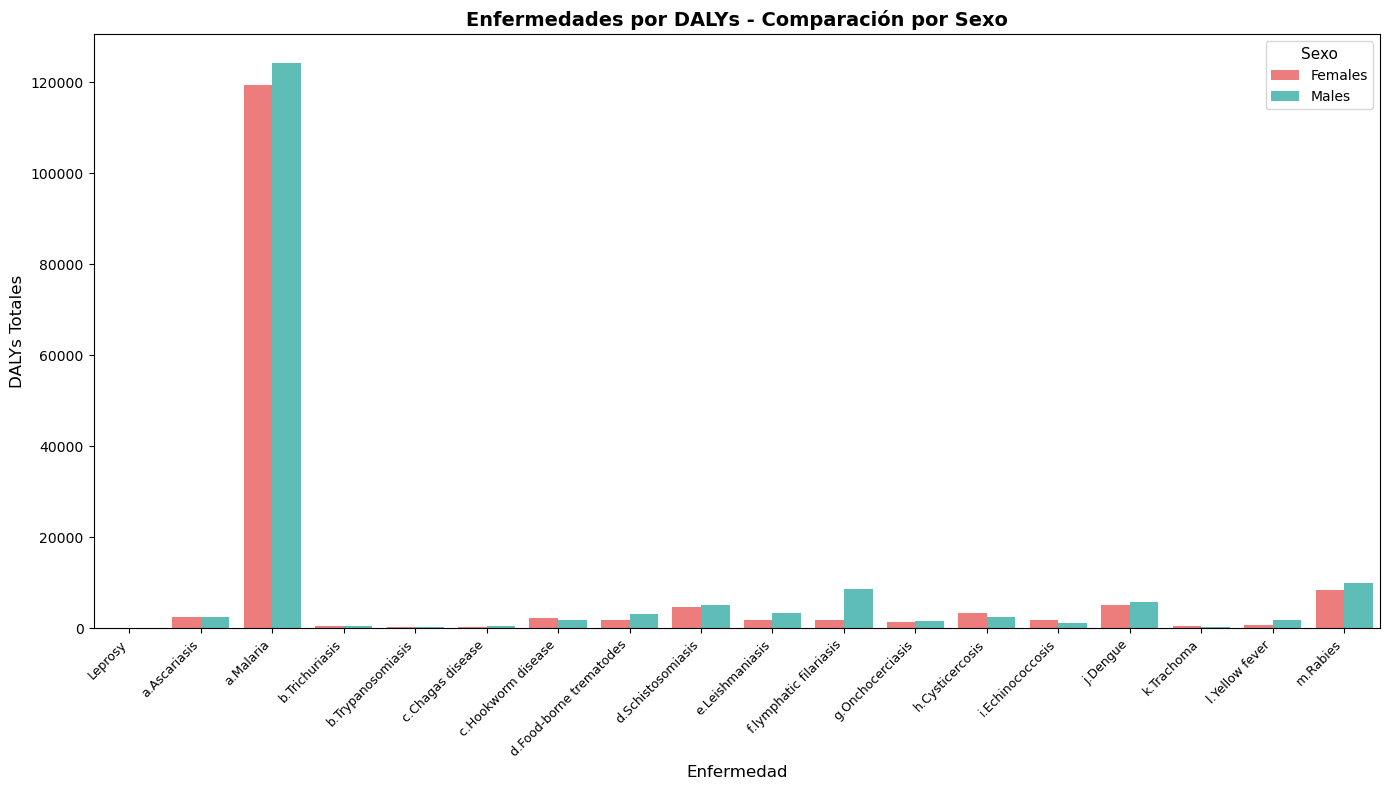

In [45]:
# Seleccionar enfermedades por DALYs totales
top_causas = dalys_causa_sexo_total.groupby('causa')['dalys'].sum().index.tolist()

# Filtrar datos para top causas
df_top = dalys_causa_sexo_total[dalys_causa_sexo_total['causa'].isin(top_causas)]

# Crear gráfico de barras agrupadas por sexo
plt.figure(figsize=(14, 8))

# Usar seaborn para barras agrupadas
sns.barplot(data=df_top, 
            x='causa', 
            y='dalys', 
            hue='sexo',
            palette=['#FF6B6B', '#4ECDC4'])

plt.title('Enfermedades por DALYs - Comparación por Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Enfermedad', fontsize=12)
plt.ylabel('DALYs Totales', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(title='Sexo', title_fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\troop\AppData\Local\Temp\ipykernel_25108\674945566.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = df_top.pivot_table(index='causa', columns='sexo', values='dalys', fill_value=0)


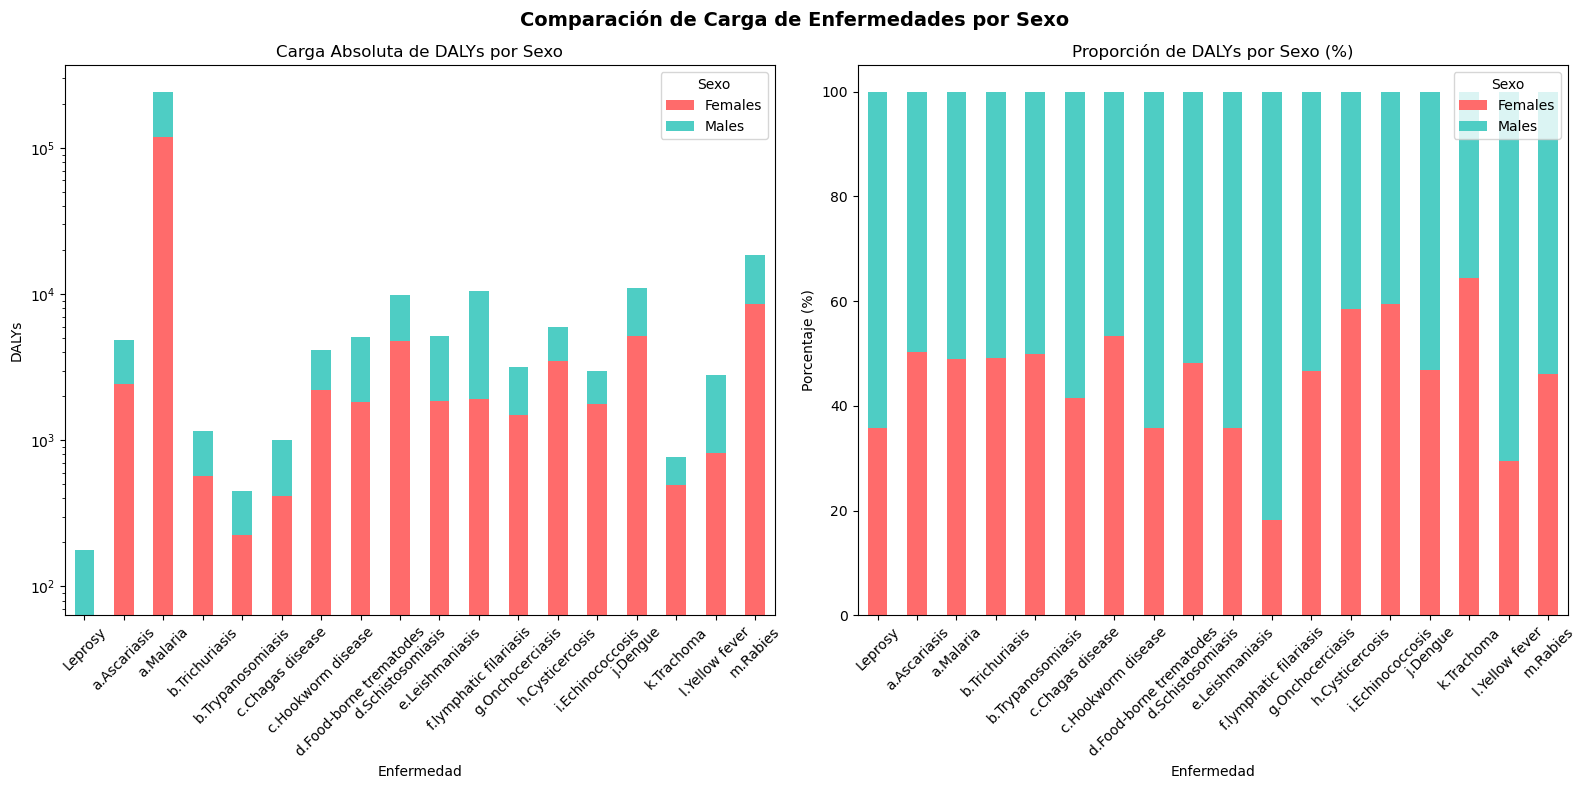

In [39]:
# Crear tabla pivote para barras apiladas
df_pivot = df_top.pivot_table(index='causa', columns='sexo', values='dalys', fill_value=0)

# Calcular porcentajes
df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Gráfico de barras apiladas (valores absolutos)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Barras apiladas - valores absolutos
df_pivot.plot(kind='bar', stacked=True, ax=ax1, color=['#FF6B6B', '#4ECDC4'], logy=True)
ax1.set_title('Carga Absoluta de DALYs por Sexo', fontsize=12)
ax1.set_xlabel('Enfermedad')
ax1.set_ylabel('DALYs')
ax1.legend(title='Sexo')
ax1.tick_params(axis='x', rotation=45)

# Barras apiladas - porcentajes
df_pivot_pct.plot(kind='bar', stacked=True, ax=ax2, color=['#FF6B6B', '#4ECDC4'])
ax2.set_title('Proporción de DALYs por Sexo (%)', fontsize=12)
ax2.set_xlabel('Enfermedad')
ax2.set_ylabel('Porcentaje (%)')
ax2.legend(title='Sexo')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Comparación de Carga de Enfermedades por Sexo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

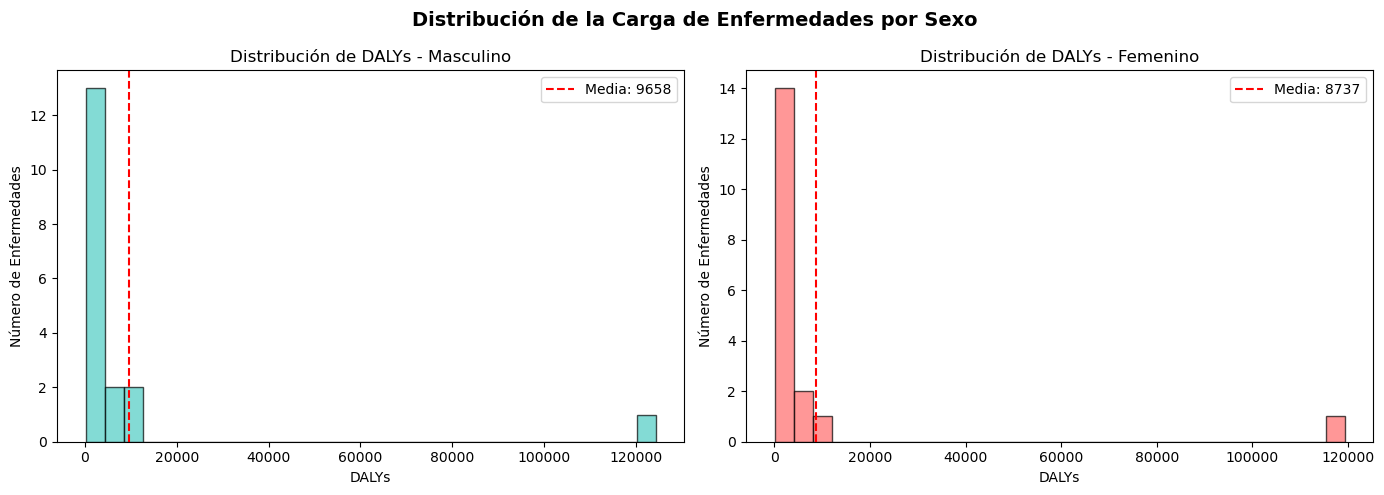

In [35]:
# Histograma de distribución de DALYs por enfermedad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma para Masculino
dalys_males = dalys_causa_sexo_total[dalys_causa_sexo_total['sexo'] == 'Males']['dalys']
axes[0].hist(dalys_males, bins=30, alpha=0.7, color='#4ECDC4', edgecolor='black')
axes[0].set_xlabel('DALYs')
axes[0].set_ylabel('Número de Enfermedades')
axes[0].set_title('Distribución de DALYs - Masculino')
axes[0].axvline(dalys_males.mean(), color='red', linestyle='--', label=f'Media: {dalys_males.mean():.0f}')
axes[0].legend()

# Histograma para Femenino
dalys_females = dalys_causa_sexo_total[dalys_causa_sexo_total['sexo'] == 'Females']['dalys']
axes[1].hist(dalys_females, bins=30, alpha=0.7, color='#FF6B6B', edgecolor='black')
axes[1].set_xlabel('DALYs')
axes[1].set_ylabel('Número de Enfermedades')
axes[1].set_title('Distribución de DALYs - Femenino')
axes[1].axvline(dalys_females.mean(), color='red', linestyle='--', label=f'Media: {dalys_females.mean():.0f}')
axes[1].legend()

plt.suptitle('Distribución de la Carga de Enfermedades por Sexo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1301983548.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\1301983548.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot_todas = dalys_causa_sexo_total.pivot_table(


<Figure size 1400x800 with 0 Axes>

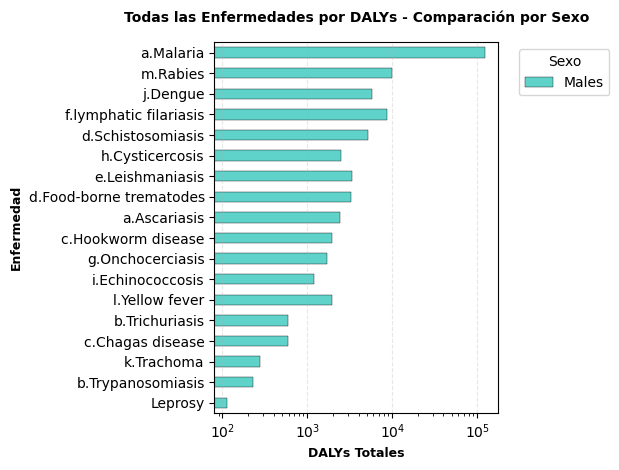

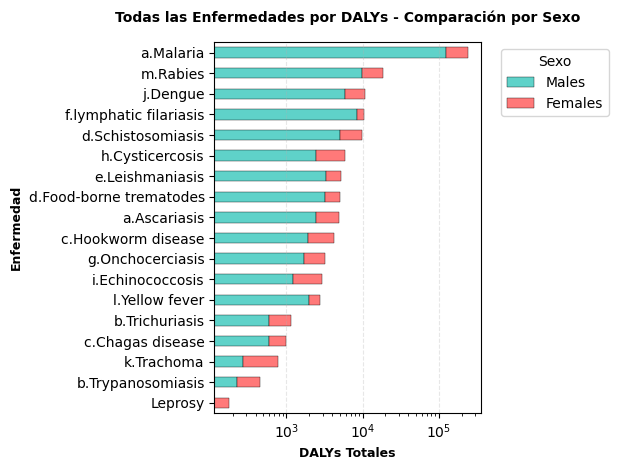

In [47]:
# ============================================
# Agregar datos por causa y sexo
# ============================================

dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()

# ============================================
# Crear tabla pivote
# ============================================

df_pivot_todas = dalys_causa_sexo_total.pivot_table(
    index='causa', 
    columns='sexo', 
    values='dalys', 
    fill_value=0
)

# ============================================
# Ordenar por total
# ============================================

df_pivot_todas['total'] = df_pivot_todas.sum(axis=1)
df_pivot_todas = df_pivot_todas.sort_values('total', ascending=True)

# ============================================
# Crear gráfico
# ============================================

# Calcular altura dinámica basada en número de enfermedades
altura = max(8, len(df_pivot_todas) * 0.3)
plt.figure(figsize=(14, altura)) 

# Verificar qué columnas de sexo están disponibles para graficar
columnas_para_graficar = []
for col in ['Males', 'Females']:
    if col in df_pivot_todas.columns:
        columnas_para_graficar.append(col)
    
    # Graficar
    ax = df_pivot_todas[columnas_para_graficar].plot(
        kind='barh', 
        stacked=True, 
        color=['#4ECDC4', '#FF6B6B'][:len(columnas_para_graficar)],
        edgecolor='black',
        linewidth=0.3,
        alpha=0.9,
        logx=True
    )
    
    # Personalizar
    plt.title(f'Todas las Enfermedades por DALYs - Comparación por Sexo', 
              fontsize=10, fontweight='bold', pad=15)
    plt.xlabel('DALYs Totales', fontsize=9, fontweight='bold')
    plt.ylabel('Enfermedad', fontsize=9, fontweight='bold')

    # Grid y leyenda
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

C:\Users\troop\AppData\Local\Temp\ipykernel_25108\2268314769.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()
C:\Users\troop\AppData\Local\Temp\ipykernel_25108\2268314769.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dalys_causa_sexo_total, x='sexo', y='dalys',


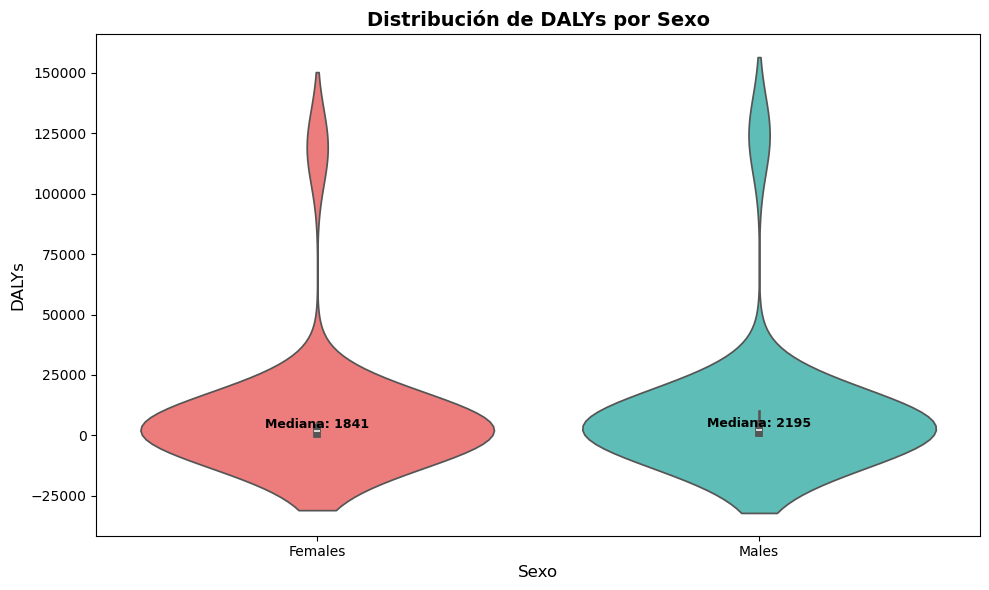

In [51]:
# Agregar por causa y sexo
dalys_causa_sexo_total = df.groupby(['causa', 'sexo'])['dalys'].sum().reset_index()

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Violinplot por sexo
sns.violinplot(data=dalys_causa_sexo_total, x='sexo', y='dalys', 
               ax=ax, palette=['#FF6B6B', '#4ECDC4'])

ax.set_title('Distribución de DALYs por Sexo', fontsize=14, fontweight='bold')
ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('DALYs', fontsize=12)

# Añadir estadísticas descriptivas
for i, sexo in enumerate(dalys_causa_sexo_total['sexo'].unique()):
    datos_sexo = dalys_causa_sexo_total[dalys_causa_sexo_total['sexo'] == sexo]['dalys']
    mediana = datos_sexo.median()
    ax.text(i, mediana, f'Mediana: {mediana:.0f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\troop\AppData\Local\Temp\ipykernel_20536\503176996.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_por_año = df.groupby(['causa', 'sexo', 'ano'])['dalys'].sum().reset_index()


Total de enfermedades: 18
Número de enfermedades: 18
Altura del gráfico: 10.8 pulgadas


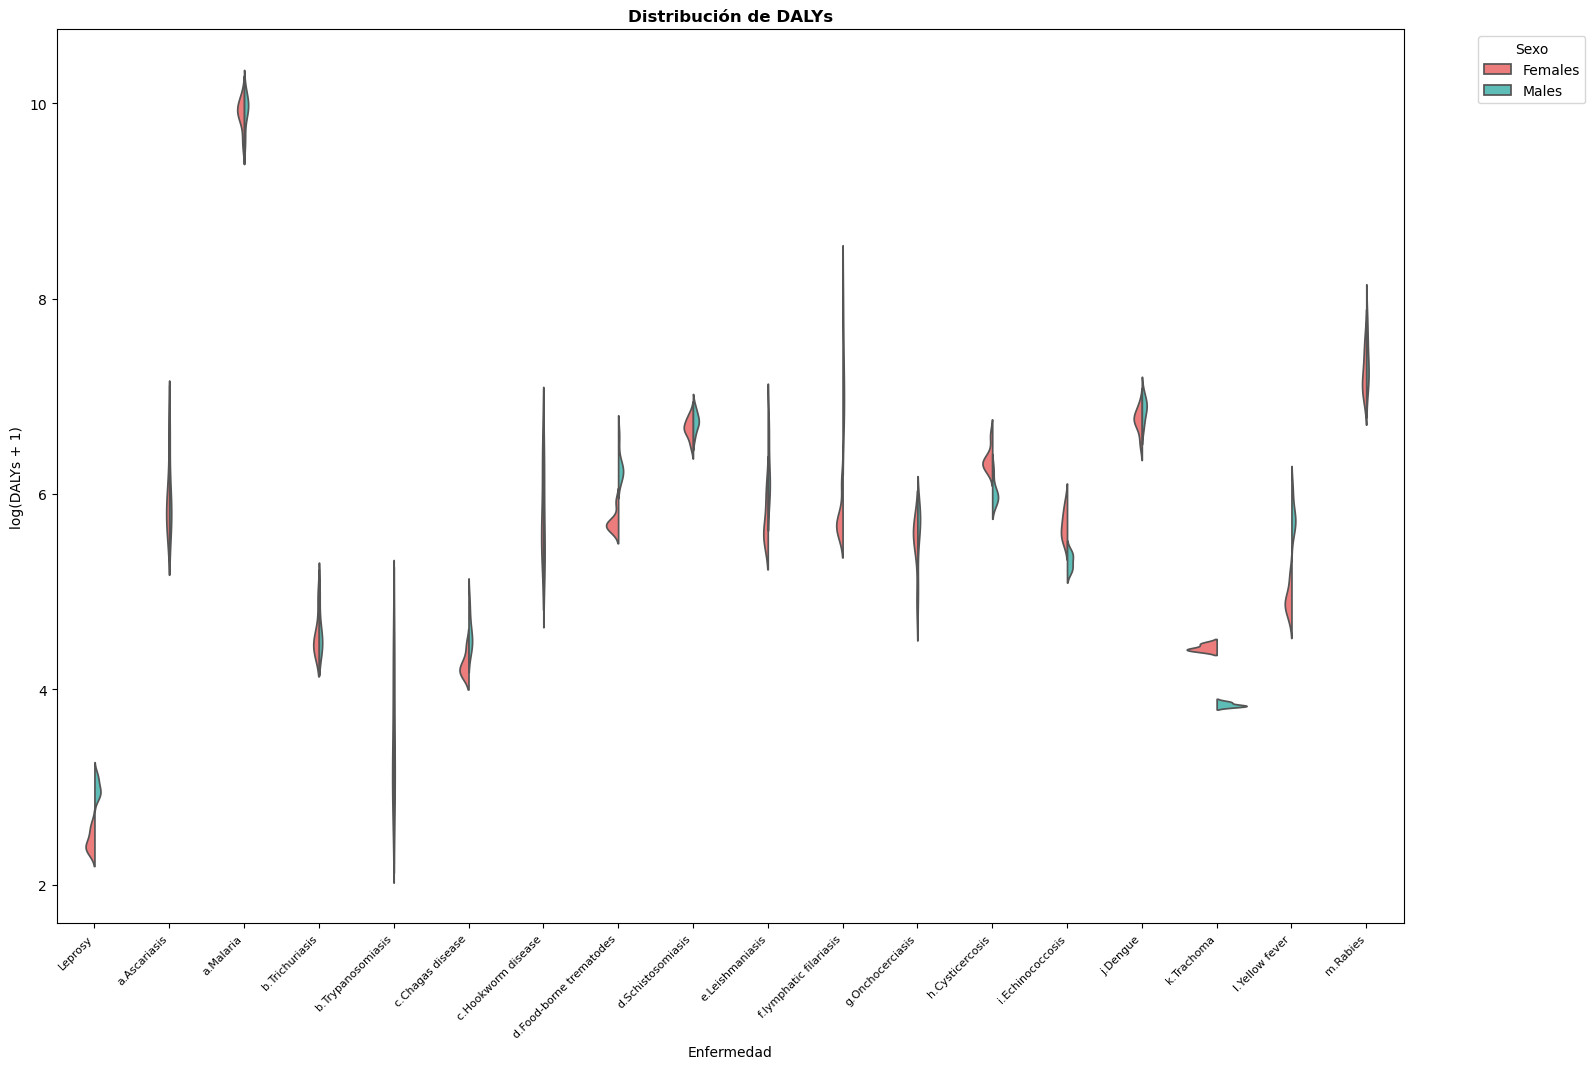

In [ ]:
dalys_por_año = df.groupby(['causa', 'sexo', 'ano'])['dalys'].sum().reset_index()

# Obtener TODAS las causas
todas_causas = dalys_por_año['causa'].unique().tolist()
print(f"Total de enfermedades: {len(todas_causas)}")

# Usar todas las causas
df_todas = dalys_por_año

# Aplicar log
df_todas['dalys_log'] = np.log1p(df_todas['dalys'])

# Calcular altura dinámica
n_causas = len(todas_causas)
altura_dinamica = max(10, n_causas * 0.6)

print(f"Número de enfermedades: {n_causas}")
print(f"Altura del gráfico: {altura_dinamica:.1f} pulgadas")

# Crear figura
plt.figure(figsize=(16, altura_dinamica))

# Violinplot SIN boxplots (inner=None elimina cualquier estadística interna)
sns.violinplot(data=df_todas, x='causa', y='dalys_log', hue='sexo',
               palette=['#FF6B6B', '#4ECDC4'], 
               split=True,
               inner=None) 

plt.title(f'Distribución de DALYs', 
          fontsize=12, fontweight='bold')
plt.xlabel('Enfermedad', fontsize=10)
plt.ylabel('log(DALYs + 1)', fontsize=10)

# Ajustar rotación de etiquetas
if n_causas > 50:
    plt.xticks(rotation=90, ha='right', fontsize=5)
elif n_causas > 30:
    plt.xticks(rotation=45, ha='right', fontsize=6)
else:
    plt.xticks(rotation=45, ha='right', fontsize=8)

plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Correlaciones

ValueError: too many values to unpack (expected 2)

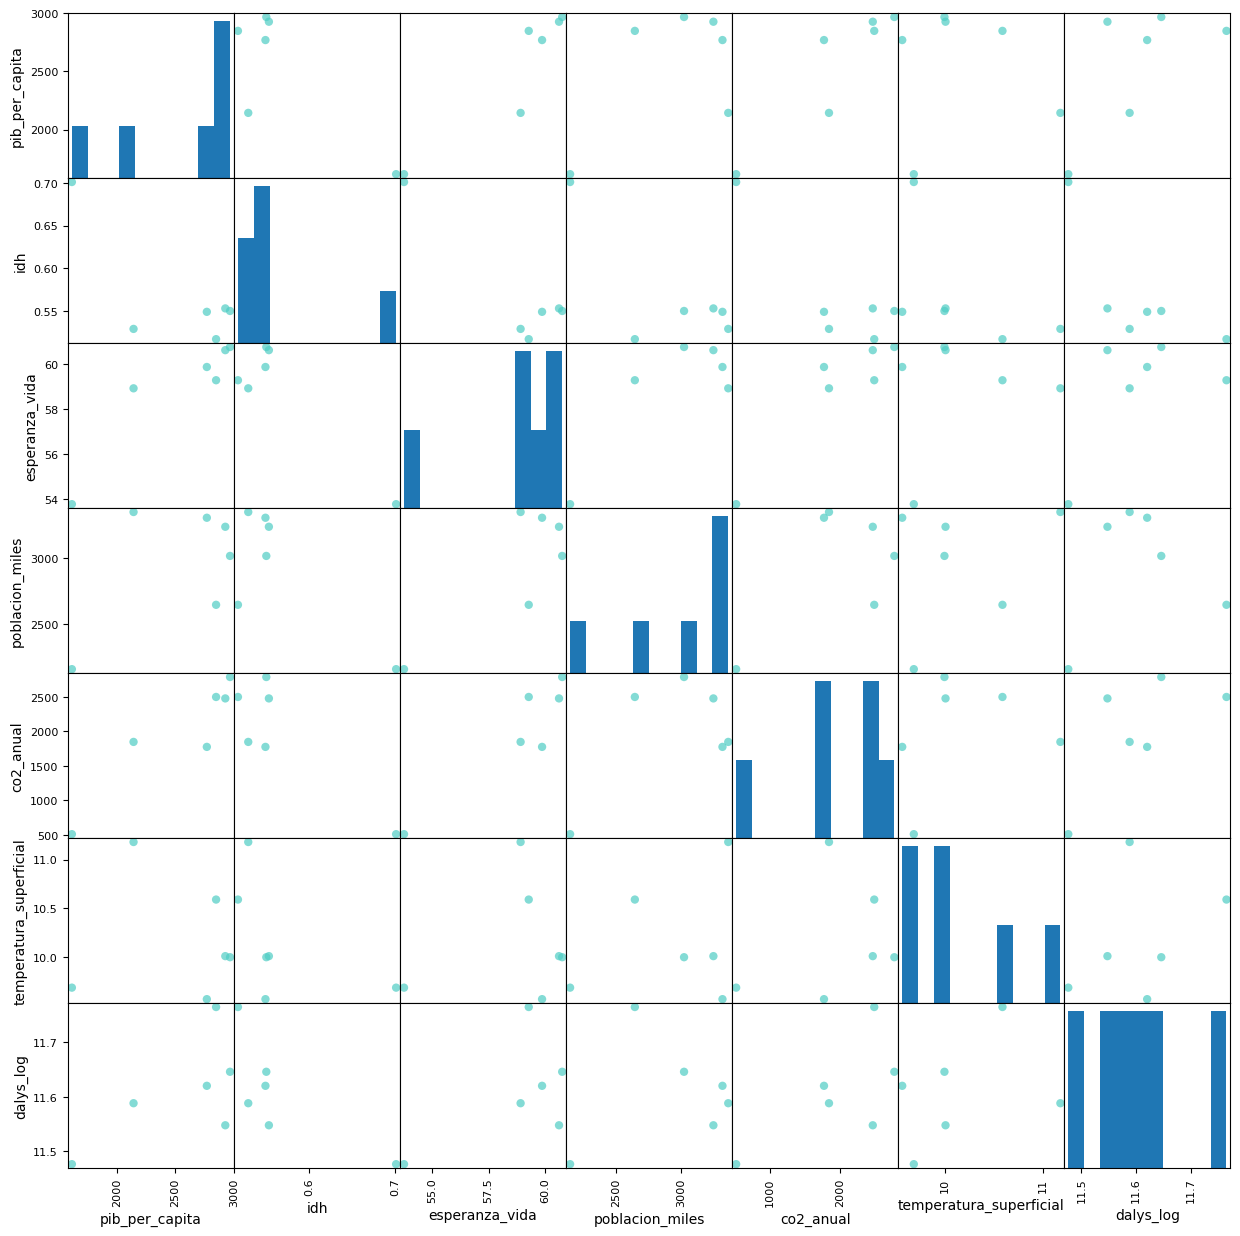

In [11]:
# Seleccionar variables para la matriz de dispersión
# Incluir DALYs y variables contextuales principales
variables_scatter = ['dalys', 'pib_per_capita', 'idh', 'esperanza_vida', 
                     'poblacion_miles', 'co2_anual', 'temperatura_superficial']

# Crear subconjunto con estas variables
df_scatter = df_analisis_global[variables_scatter].copy()

# Aplicar log a DALYs si está muy sesgado
df_scatter['dalys_log'] = np.log1p(df_scatter['dalys'])

# Opción 1: Usar dalys original o log
df_scatter_plot = df_scatter.drop('dalys', axis=1)  # Usar dalys_log en su lugar

# Crear scatter matrix
fig, axes = scatter_matrix(df_scatter_plot, 
                           alpha=0.7, 
                           figsize=(15, 15),
                           diagonal='hist',  # histogramas en la diagonal
                           marker='o',
                           color='#4ECDC4')

# Ajustar títulos y rotación
for ax in axes.flatten():
    ax.xaxis.set_label_rotation(45)
    ax.yaxis.set_label_rotation(0)
    ax.xaxis.set_label_coords(0.5, -0.1)
    ax.yaxis.set_label_coords(-0.1, 0.5)

plt.suptitle('Matriz de Dispersión: DALYs vs Variables Contextuales (Global por Año)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\troop\AppData\Local\Temp\ipykernel_20536\2824346282.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_paises = df_analisis_pais.groupby('pais')['dalys'].sum().nlargest(10).index.tolist()


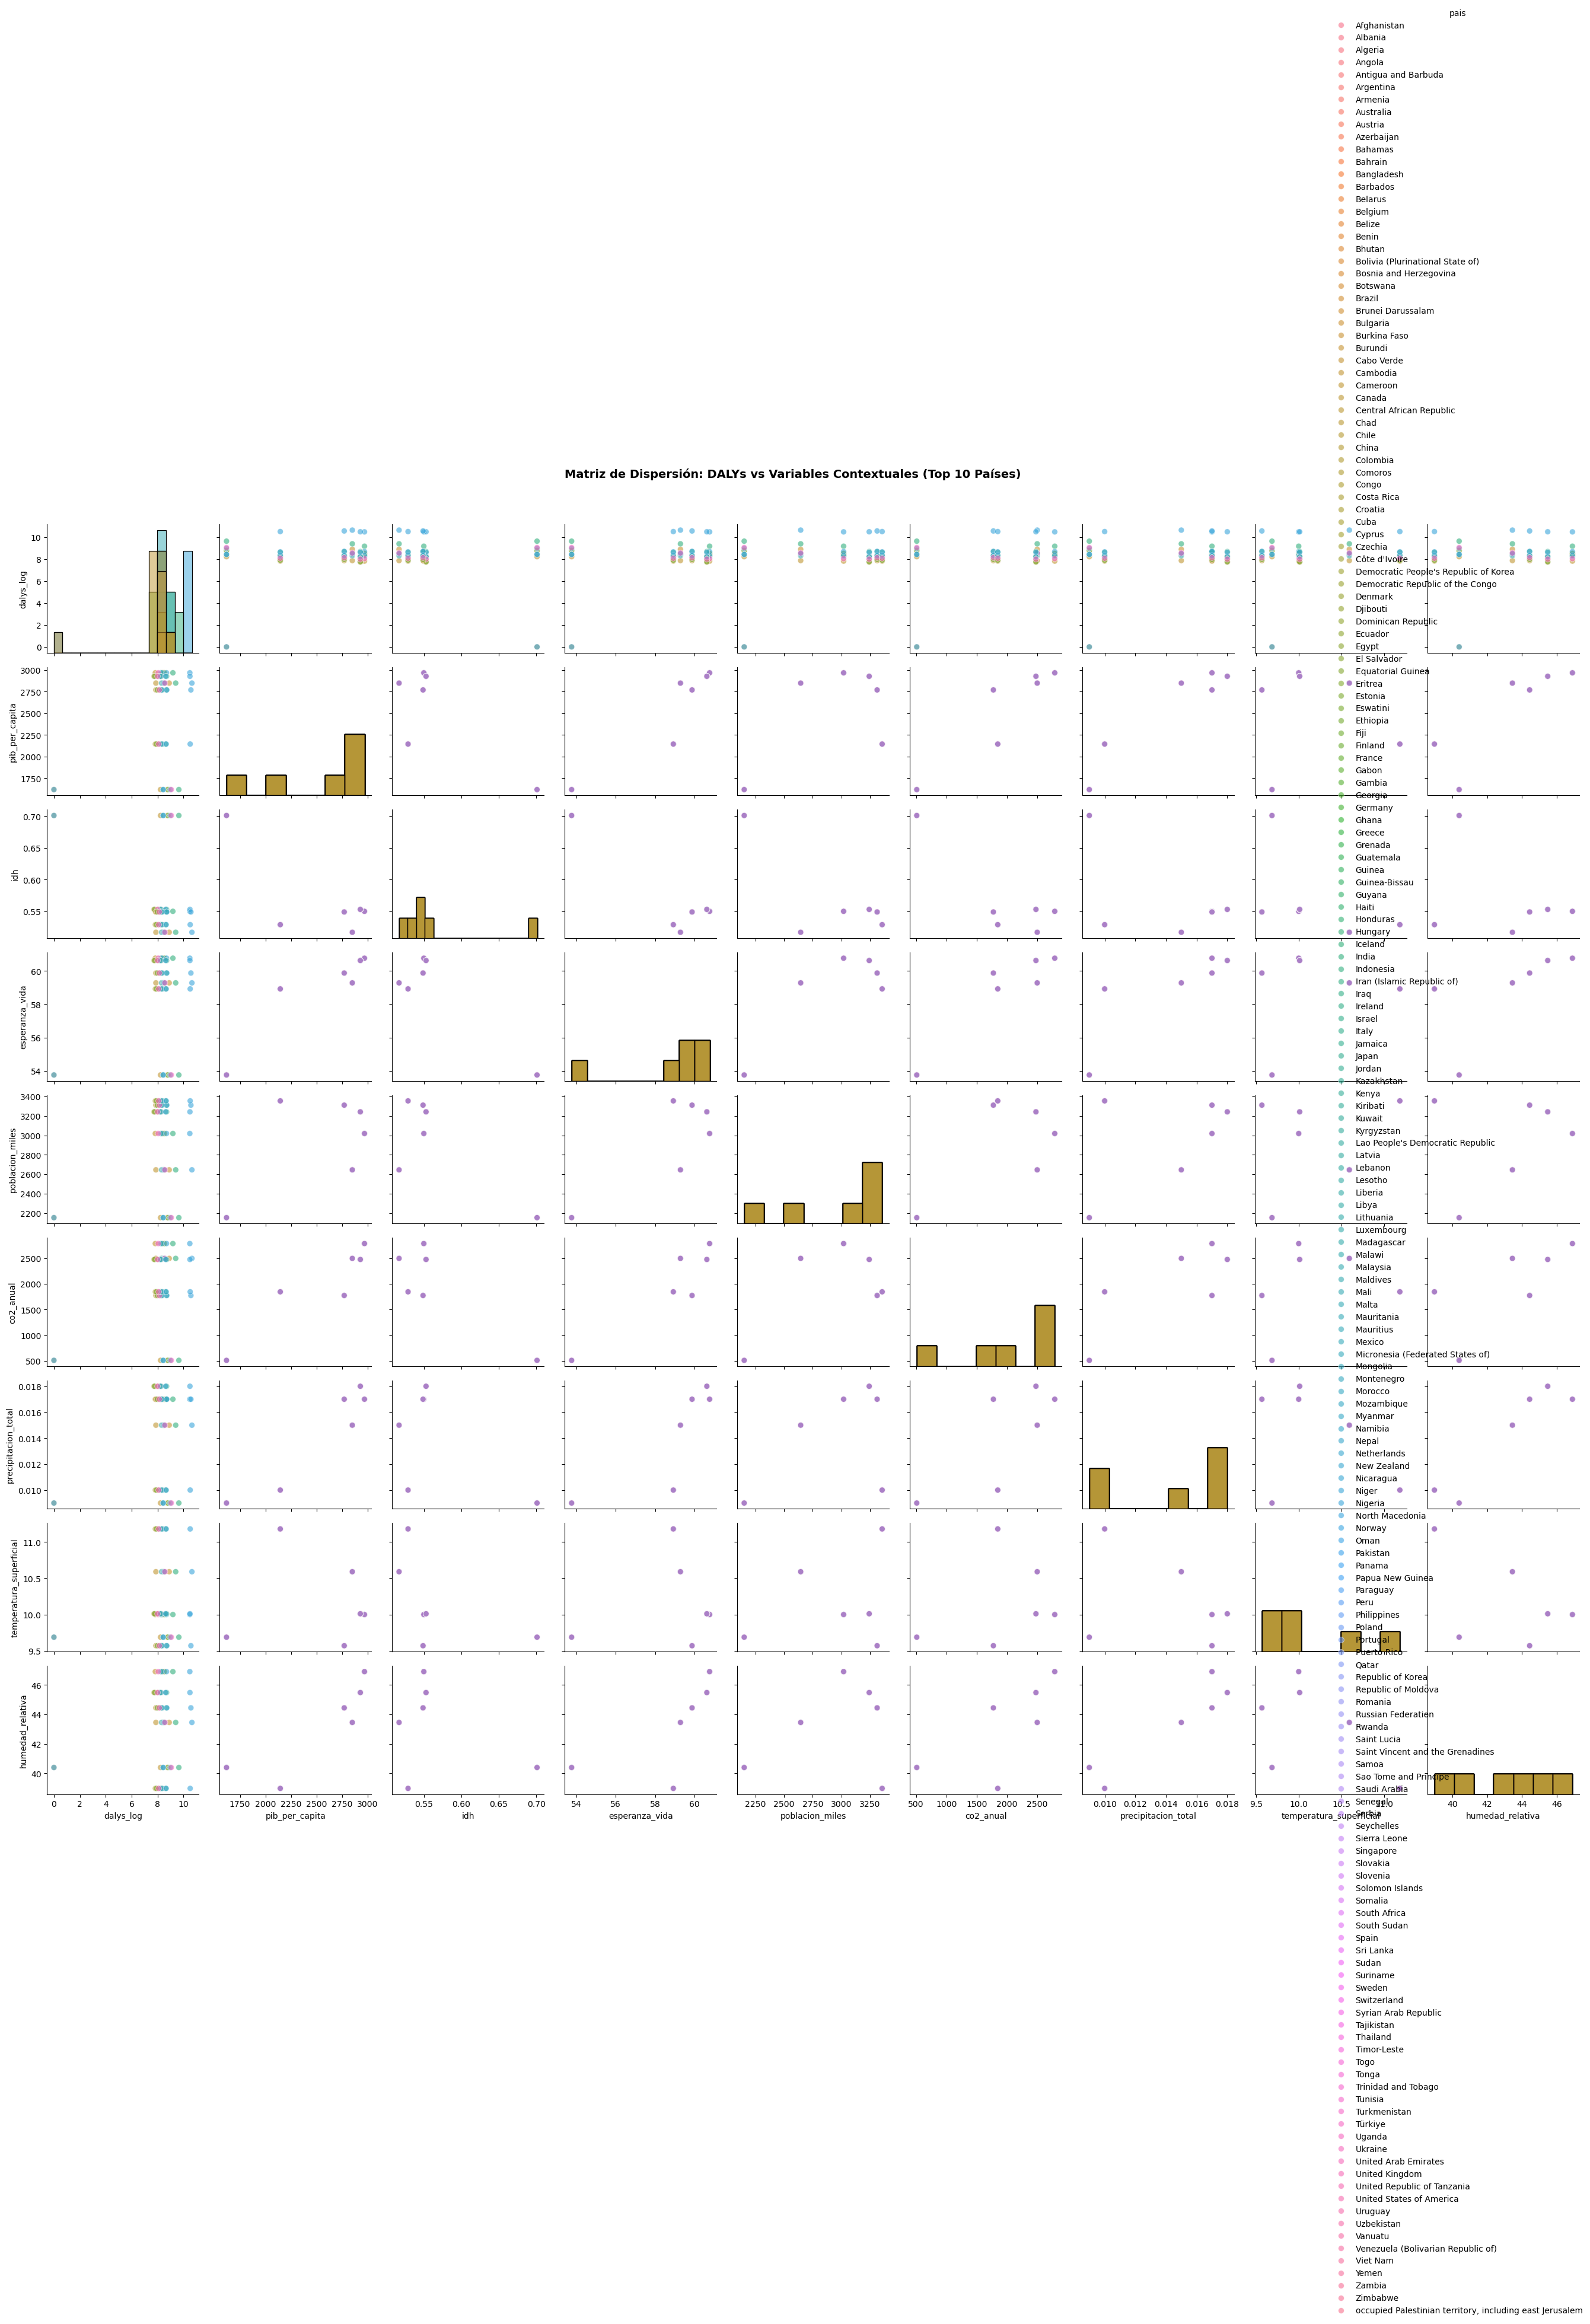

In [16]:
# ============================================
# Scatter Matrix por país (con colores por país)
# ============================================

import seaborn as sns

# Seleccionar un subconjunto de países para no saturar (ej: top 10)
top_paises = df_analisis_pais.groupby('pais')['dalys'].sum().nlargest(10).index.tolist()
df_top_paises = df_analisis_pais[df_analisis_pais['pais'].isin(top_paises)]

# Seleccionar variables
variables_scatter = ['dalys', 'pib_per_capita', 'idh', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 
                     'humedad_relativa']
df_scatter_paises = df_top_paises[variables_scatter + ['pais']].copy()

# Aplicar log
df_scatter_paises['dalys_log'] = np.log1p(df_scatter_paises['dalys'])

# Crear pairplot de seaborn (más bonito que scatter_matrix)
g = sns.pairplot(df_scatter_paises, 
                 vars=['dalys_log', 'pib_per_capita', 'idh', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 
                     'humedad_relativa'],
                 hue='pais',
                 palette='husl',
                 diag_kind='hist',
                 plot_kws={'alpha': 0.6, 's': 50},
                 height=2.5)

g.fig.suptitle('Matriz de Dispersión: DALYs vs Variables Contextuales (Top 10 Países)', 
               fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\troop\AppData\Local\Temp\ipykernel_20536\698631914.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_causas = df_analisis_categoria.groupby('causa')['dalys'].sum().nlargest(8).index.tolist()


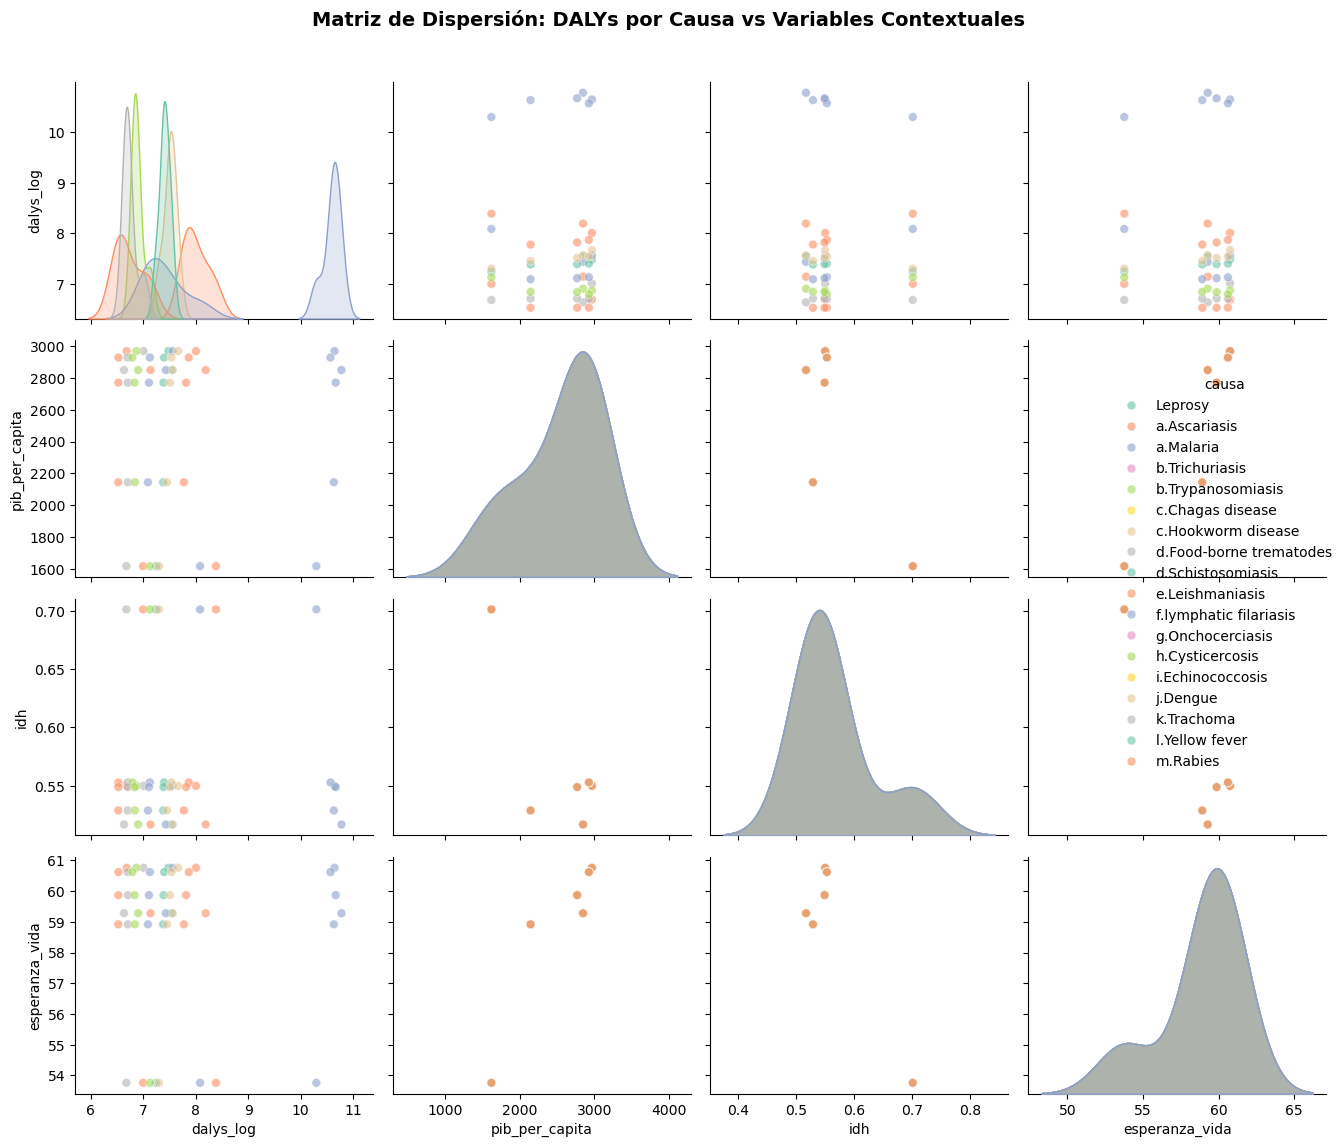

In [ ]:
# ============================================
# Scatter Matrix por categoría de enfermedad
# ============================================

# Seleccionar top causas para visualizar
top_causas = df_analisis_categoria.groupby('causa')['dalys'].sum().nlargest(8).index.tolist()
df_top_causas = df_analisis_categoria[df_analisis_categoria['causa'].isin(top_causas)]

# Seleccionar variables
variables_scatter = ['dalys', 'pib_per_capita', 'idh', 'esperanza_vida', 'poblacion_miles', ]
df_scatter_causas = df_top_causas[variables_scatter + ['causa']].copy()

# Aplicar log
df_scatter_causas['dalys_log'] = np.log1p(df_scatter_causas['dalys'])

# Crear pairplot
g = sns.pairplot(df_scatter_causas, 
                 vars=['dalys_log', 'pib_per_capita', 'idh', 'esperanza_vida'],
                 hue='causa',
                 palette='Set2',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40},
                 height=2.8)

g.fig.suptitle('Matriz de Dispersión: DALYs por Causa vs Variables Contextuales', 
               fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

IndexError: index 5 is out of bounds for axis 1 with size 5

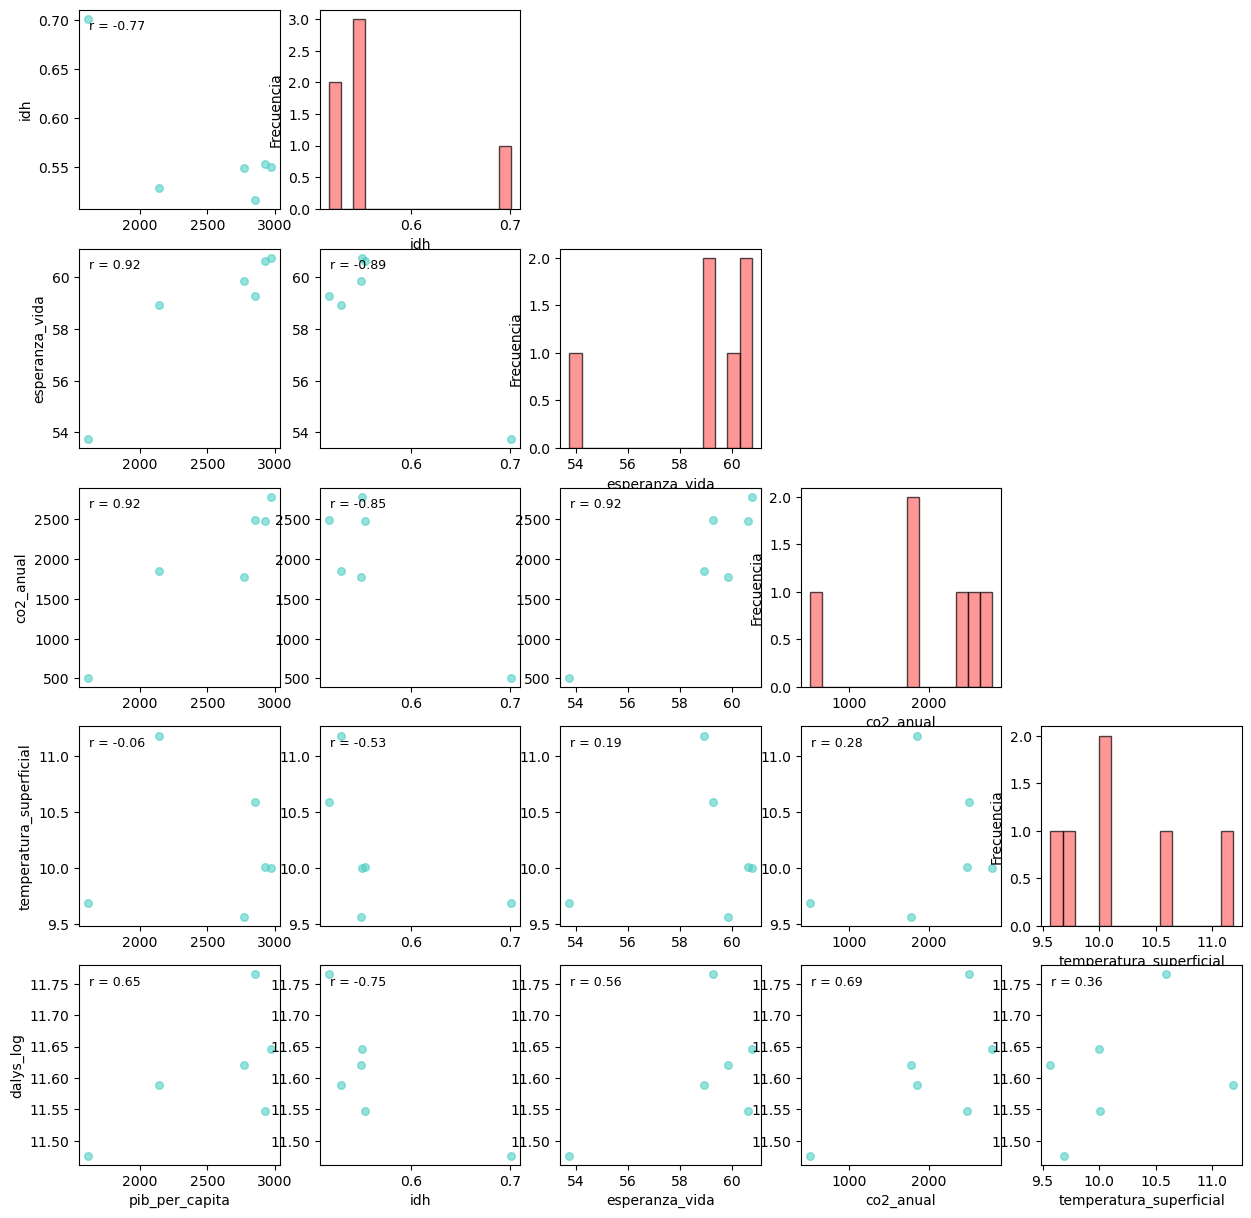

In [19]:
# ============================================
# Scatter Matrix con correlaciones
# ============================================

# Seleccionar variables
variables = ['dalys', 'pib_per_capita', 'idh', 'esperanza_vida', 'co2_anual', 'temperatura_superficial']
df_corr = df_analisis_global[variables].copy()

# Aplicar log a DALYs
df_corr['dalys_log'] = np.log1p(df_corr['dalys'])
df_corr = df_corr.drop('dalys', axis=1)

# Calcular matriz de correlación
corr_matrix = df_corr.corr()

# Crear figura con subplots
fig, axes = plt.subplots(len(variables)-1, len(variables)-1, 
                         figsize=(15, 15), 
                         facecolor='white')

for i, var1 in enumerate(df_corr.columns):
    for j, var2 in enumerate(df_corr.columns):
        if i > j:
            ax = axes[i-1, j]
            ax.scatter(df_corr[var2], df_corr[var1], alpha=0.6, color='#4ECDC4', s=30)
            
            # Calcular correlación
            corr_val = corr_matrix.loc[var1, var2]
            ax.text(0.05, 0.95, f'r = {corr_val:.2f}', 
                   transform=ax.transAxes, fontsize=9, verticalalignment='top')
            
            # Ajustar etiquetas
            if i == len(df_corr.columns)-1:
                ax.set_xlabel(var2, fontsize=10)
            if j == 0:
                ax.set_ylabel(var1, fontsize=10)
                
            # Eliminar axes no utilizados
        elif i == j:
            ax = axes[i-1, j] if i > 0 else None
            if ax is not None:
                ax.hist(df_corr[var1], bins=15, color='#FF6B6B', alpha=0.7, edgecolor='black')
                ax.set_xlabel(var1, fontsize=10)
                ax.set_ylabel('Frecuencia', fontsize=10)
        else:
            if i > 0 and j < len(df_corr.columns)-1:
                ax = axes[i-1, j]
                ax.set_visible(False)

plt.suptitle('Matriz de Dispersión con Correlaciones', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Mostrar matriz de correlación
print("\n📊 Matriz de Correlación:")
print(corr_matrix.round(3))

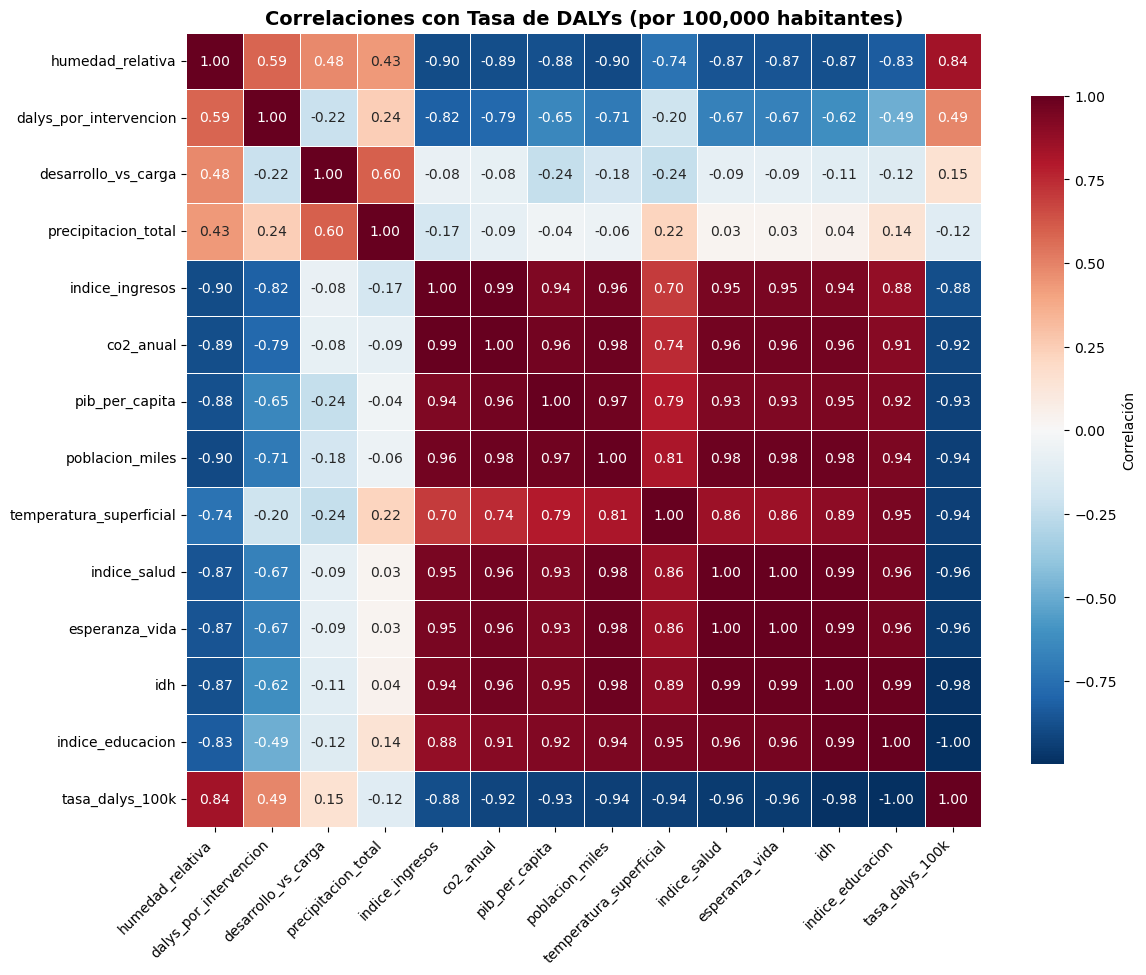


📈 Correlaciones con Tasa de DALYs:
humedad_relativa           0.842
dalys_por_intervencion     0.486
desarrollo_vs_carga        0.155
precipitacion_total       -0.120
indice_ingresos           -0.884
co2_anual                 -0.916
pib_per_capita            -0.934
poblacion_miles           -0.942
temperatura_superficial   -0.944
indice_salud              -0.957
esperanza_vida            -0.957
idh                       -0.985
indice_educacion          -0.999
Name: tasa_dalys_100k, dtype: float64


In [27]:
# ============================================
# HEATMAP DE CORRELACIONES - Usando variables existentes
# ============================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('data_clean/DALYs_clean_unificado_NEW.csv')

# Variables a analizar (usando las que ya tienes)
variables = [
    'tasa_dalys_100k',           # Variable objetivo (ajustada por población)
    'pib_per_capita',            
    'idh',                       
    'indice_educacion',          
    'indice_salud',              
    'indice_ingresos',           
    'esperanza_vida',            
    'poblacion_miles',           
    'co2_anual',                 
    'precipitacion_total',       
    'temperatura_superficial',   
    'humedad_relativa',
    'dalys_por_intervencion',    
    'desarrollo_vs_carga'        
]

# Filtrar variables existentes
variables = [var for var in variables if var in df.columns]

# Agregar por año (promediar las variables)
df_agregado = df.groupby('ano')[variables].mean().reset_index()

# Matriz de correlación
df_corr = df_agregado[variables].corr()

# Ordenar por correlación con tasa_dalys_100k
corr_tasa = df_corr['tasa_dalys_100k'].drop('tasa_dalys_100k').sort_values(ascending=False)
vars_ordenadas = corr_tasa.index.tolist() + ['tasa_dalys_100k']
df_corr_ordenada = df_corr.loc[vars_ordenadas, vars_ordenadas]

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr_ordenada, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación"})
plt.title('Correlaciones con Tasa de DALYs (por 100,000 habitantes)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mostrar correlaciones
print("\n📈 Correlaciones con Tasa de DALYs:")
print(corr_tasa.round(3))